# Toy example classification

In this notebook, we are going to introduce concepts linked to classification via synthetic datasets. This will stand as an introduction to the classification of audio signal which will be done in later notebooks.

There exists a lot of different classification models in the literature. In this notebook we propose to play with two simple and intuitive classifiers: the K-Nearest-Neighbour (``KNN``) classifier and the Linear Discriminant Analysis (``LDA``) classifier. The related Wikipedia page are [KNN](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm) and [LDA](https://en.wikipedia.org/wiki/Linear_discriminant_analysis). <br>
Made simple, KNN and LDA are ``supervised machine learning algorithms``. For KNN, each new point to be classified is compared with its K nearest neighbours among labelled data (i.e. points whose class is known) in the dataspace with respect to a chosen distance metric. For LDA, the data distributions of the classes are assumed to be normal, i.i.d. and with the same covariance. The decision boundaries are set to areas in the distribution space where the log-likelihood that the data belongs to another class is higher than the true class. It is worth noticing that the LDA classifier is a parametric model while KNN is not. Indeed, KNN has only one hyperparameter $K$, but the learning phase simply consist of saving the learning set in memory to be used later for inference.  <br>

To avoid reinventing the wheel, we will use the implementations provided by ``sklearn``. You are strongly encouraged to have a look at the documentation [for the KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) and [for the LDA](https://scikit-learn.org/stable/modules/lda_qda.html?highlight=lda). We will also use ``pickle`` for saving and loading the trained models. <br>


You will have to fill some short pieces of code, as well as answer some questions. We already created cells for you to answer the questions to ensure you don't forget it ;). <br>
You will find the zones to be briefly filled  with a ``### TO COMPLETE`` in the cells below.

In [1]:
### TO RUN
import matplotlib.pyplot as plt
import numpy as np

"Machine learning tools"
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier

from classification.utils.plots import plot_decision_boundaries, show_confusion_matrix
from classification.utils.utils import accuracy

# Getting intuition with a toy example

Before going deep into classifying the complicated feature vectors we designed in H1, let us analyze a toy example. <br>
It is always good practice to make some trials on a simplified version of a problem before tackling it. It prevents from a big amount of time loss and some strange dark bugs. <br>

The convention used by ``sklearn`` is that $\boldsymbol{X}$ is a matrix whose height is the number $N$ of samples in the dataset and width is the dimension $p$ of each feature vector, as depicted here below (one colour is one class). It writes 
\begin{equation*}
    \boldsymbol X = (\boldsymbol x_1, \cdots, \boldsymbol x_N)^\top
\end{equation*}

with $\boldsymbol x_i \in \mathbb R^p$ the feature vector of the $i$-th sample whose class is encoded in $y_i$, i.e. 
\begin{equation*}
    y_i \in \{\text{'Class 0'}, \cdots, \text{'Class 3'}\}
\end{equation*}

<center> <img src="figs/Xy.svg" alt=""  width="500"/> </center>

<font size=6 color=#009999> 1. Detection problem </font> <br>

Let's first generate some synthetic data with some classes.


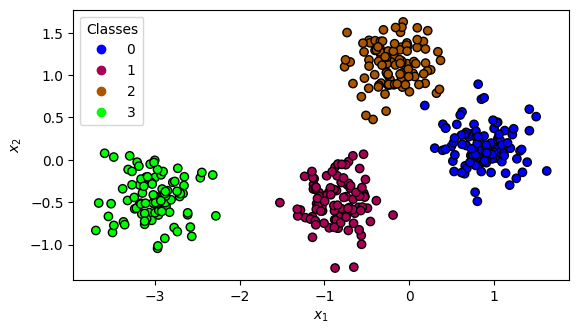

In [19]:
### TO RUN
normalize = False
N = 100  # Number of points per subcluster. (defaut: 100)
n_classes = 4  # Number of differents classes. (default: 4)
sig = 0.25  # Noise std. (default: 0.25)
np.random.seed(
    70
)  # For some reproducibility in the results, you can change the seed or remove this line if desired. (default: 1)


"Generate the data"
cluster_centers = np.random.randn(n_classes * 1, 2),

centers = np.repeat(cluster_centers, N, axis=1)
noise = sig * np.random.randn(n_classes * N, 2)
X = (centers + noise)[0]
if normalize:
    X /= np.linalg.norm(X, axis=1, keepdims=True)
y = np.repeat(np.arange(n_classes), N)

"Plot"
cm = "brg"
edgc = "k"
fig = plt.figure()

ax = plt.gca()
ax.set_aspect("equal", adjustable="box")
scatterd = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm, edgecolors=edgc)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
handles, labels = scatterd.legend_elements(prop="colors")
ax.legend(handles, labels, title="Classes")
plt.show()

In practice, we will not know if a sample belongs to any class.
To represent this, we will create a new class which will be considered as pure noise.
The problem of detection is a problem of binary classification "does belong to any class" or "does not belong to any class".

C:\Users\Mani\AppData\Local\Temp\ipykernel_9932\4263924899.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatterd = plt.scatter(X[:, 0], X[:, 1], c='xkcd:green', cmap=cm, edgecolors=edgc, label="Valid points")
C:\Users\Mani\AppData\Local\Temp\ipykernel_9932\4263924899.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(noise[:, 0], noise[:, 1], c='xkcd:red', cmap=cm, edgecolors=edgc, label="Noise")


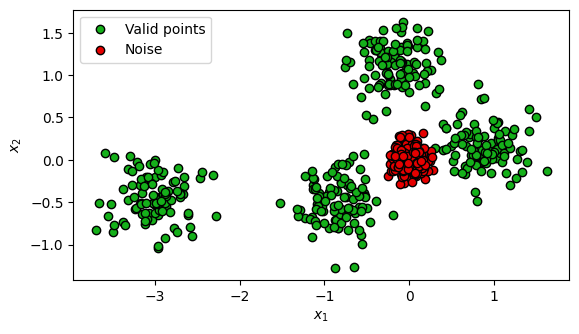

In [20]:
noise_amplitude = 0.1
noise = noise_amplitude * np.random.randn(n_classes * N, 2)

ax = plt.gca()
ax.set_aspect("equal", adjustable="box")
scatterd = plt.scatter(X[:, 0], X[:, 1], c='xkcd:green', cmap=cm, edgecolors=edgc, label="Valid points")
plt.scatter(noise[:, 0], noise[:, 1], c='xkcd:red', cmap=cm, edgecolors=edgc, label="Noise")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
ax.legend()
plt.show()

In practice, this noise will be the background noise that is constantly audible in a forest.

Here is a code which instantiates and train a KNN then the accuracy is evaluated:

Accuracy = $\frac{\text{\# Good predictions}}{\text{Total \# predictions}} = \frac{\text{TP+TN}}{\text{TP+FP+FN+TN}}$.

A hard treshold predictor based the magnitude is also evaluated.

Accuracy KNN : 99.58 %
Accuracy Hard threshold : 98.33 %


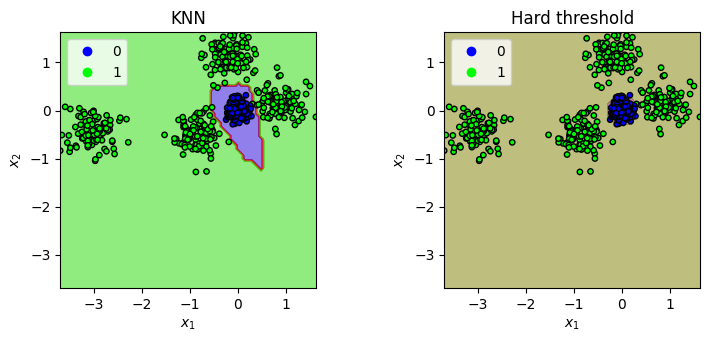

In [21]:
hard_tresh = 0.3

X_det = np.concatenate([X, noise])
y_det = np.concatenate([np.ones(len(X)), np.zeros(len(noise))])

"Shuffle the data then split in training and testing sets"
X_train, X_test, y_train, y_test = train_test_split(
    X_det, y_det, test_size=0.3, stratify=y_det
)  # 'stratify=y' ensures we pick the same number of samples per class during the splitting

K = 10  # Number of neighbours
model_knn = KNeighborsClassifier(n_neighbors=K)  # Declare the KNN classifier
model_knn.fit(X_train, y_train)  # Train the classifier
prediction_knn = model_knn.predict(X_test)
accuracy_knn = np.sum(prediction_knn - y_test == 0) / X_test.shape[0]
print(f"Accuracy KNN : {100 * accuracy_knn:.2f} %")


class Tresh: # We create this class to be able to use boundary plots later
    def predict(X):
        return np.array([np.linalg.norm(x) > hard_tresh for x in X])

    # You could imagine adding a fit function where you estimate the best threshold
    # Other strategies to evaluate a threshold exist

prediction_tresh = Tresh.predict(X_test)
accuracy_tresh = np.sum(prediction_tresh - y_test == 0) / X_test.shape[0]
print(f"Accuracy Hard threshold : {100 * accuracy_tresh:.2f} %")

s = 15.0
fig = plt.figure()
axs = [fig.add_axes([0.0, 0.0, 0.4, 0.9]), fig.add_axes([0.6, 0.0, 0.4, 0.9])]
plot_decision_boundaries(
    X_det, y_det, model_knn, ax=axs[0], legend=labels, title="KNN", s=s
)
plot_decision_boundaries(
    X_det, y_det, Tresh, ax=axs[1], legend=labels, title="Hard treshold", s=s
)


What can you observe?

What are the points that are the most difficult to detect?

Change the value of ``noise_amplitude`` and ``hard_tresh`` what do you observe?

<font size=5 color=#009999> 2.0. Classification, metrics and model evaluation </font> <br>
We will now consider that a first filtering has been applied to only keep points that effectively belong to a class. <br>
In order to objectively evaluate the performance of your classification model, the use of metrics is necessary.
[See some examples here.](https://towardsdatascience.com/the-5-classification-evaluation-metrics-you-must-know-aa97784ff226) <br>
Throughout this notebook, the two metrics we will use are:
* Accuracy, as defined in the last section, which applies as well to classification as to detection.
* Confusion matrix: add $1$ to the counter at position $(i,j)$ if the model predicted $i$ but the true label was $j$.

Please do not feel limited to those metrics in this project. Every metric found in the litterature has some specificities which may (not) fit this project.

We provide the code for the KNN classifier. For you to start handling sklearn implementations, we let you declare a LDA classifier and compute its accuracy on the test set.

Beware, the points are plotted in 2D but can belong to a space with more dimensions!


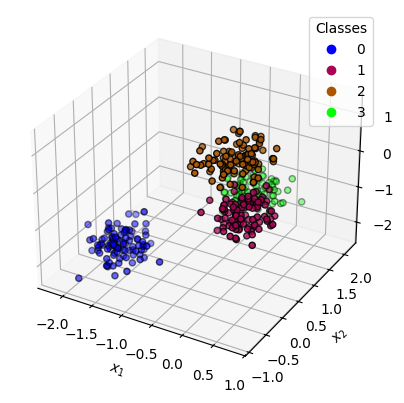

In [ ]:
### TO RUN
plot3D = True
normalize = False
N = 100  # Number of points per subcluster. (defaut: 100)
n_classes = 4  # Number of differents classes. (default: 4)
n_subclusters = 1  # Number of subclusters of points per class. (defaut: 1)
dim = 3  # Dimensionality of the point clouds. i.e., Number of dimensions of a feature vector. (defaut: 2)
dim_clusters = 2  # Dimensionality of the clusters arrangment. (default: 2)
sig = 0.25  # Noise std. (default: 0.25)
np.random.seed(
    55
)  # For some reproducibility in the results, you can change the seed or remove this line if desired. (default: 1)

M = N * n_subclusters  # Number of points per class

"Generate the data"
cluster_centers = np.concatenate(
    (
        np.random.randn(n_classes * n_subclusters, dim_clusters),
        np.zeros((n_classes * n_subclusters, dim - dim_clusters)),
    ),
    axis=1,
)
centers = np.repeat(cluster_centers, N, axis=0)
noise = sig * np.random.randn(n_classes * M, dim)
X = centers + noise
if normalize:
    X /= np.linalg.norm(X, axis=1, keepdims=True)
y = np.repeat(np.arange(n_classes), M)

print(
    "Beware, the points are plotted in 2D but can belong to a space with more dimensions!"
)

"Plot"
cm = "brg"
edgc = "k"
fig = plt.figure()
if plot3D:
    ax = plt.axes(projection="3d")
    ax.scatter3D(X[:, 0], X[:, 1], X[:, 2], c=y, cmap=cm, edgecolor=edgc)
else:
    ax = plt.gca()
    ax.set_aspect("equal", adjustable="box")
    scatterd = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm, edgecolors=edgc)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
handles, labels = scatterd.legend_elements(prop="colors")
ax.legend(handles, labels, title="Classes")
plt.show()

Accuracy KNN : 94.17 %
Accuracy LDA : 95.00 %


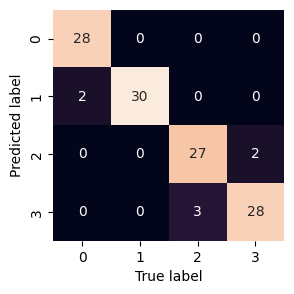

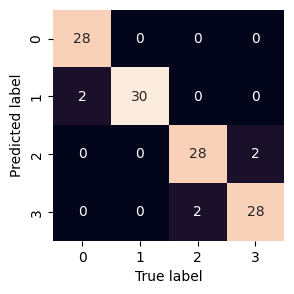

In [38]:
"Shuffle the data then split in training and testing sets"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)  # 'stratify=y' en Image sures we pick the same number of samples per class during the splitting

K = 10  # Number of neighbours
model_knn = KNeighborsClassifier(n_neighbors=K)  # Declare the KNN classifier
model_knn.fit(X_train, y_train)  # Train the classifier
prediction_knn = model_knn.predict(X_test)
accuracy_knn = np.sum(prediction_knn - y_test == 0) / X_test.shape[0]
print(f"Accuracy KNN : {100 * accuracy_knn:.2f} %")

model_lda = LDA()  # Declare the LDA classifier with parameters by default.
### TO COMPLETE
model_lda.fit(X_train, y_train)  # Train the classifier
prediction_lda = model_lda.predict(X_test)
accuracy_lda = np.sum(prediction_lda - y_test == 0) / X_test.shape[0]
print(f"Accuracy LDA : {100 * accuracy_lda:.2f} %")

"Plot"
if dim == 2:
    # Plot the decision boundary.
    s = 15.0
    fig = plt.figure()
    axs = [fig.add_axes([0.0, 0.0, 0.4, 0.9]), fig.add_axes([0.6, 0.0, 0.4, 0.9])]
    plot_decision_boundaries(
        X, y, model_knn, ax=axs[0], legend=labels, title="KNN", s=s
    )
    plot_decision_boundaries(
        X, y, model_lda, ax=axs[1], legend=labels, title="LDA", s=s
    )
    # plt.show()

axs[0].set_title("KNN")
show_confusion_matrix(prediction_knn, y_test, np.arange(n_classes))
axs[1].set_title("LDA using rbf kernel")
show_confusion_matrix(prediction_lda, y_test, np.arange(n_classes))

It's already time for some analysis (**put the default parameters when unspecified**):

1) Which accuracy would you expect from a classifier choosing uniformly at random?
2) Can you explain what would make two classes be confused one for the other?
3) Play with ``n_classes``, how do the accuracy and the confusion matrix evolve with it?
4) Play with ``sig``, how do the accuracy and the confusion matrix evolve with it?
5) Fix ``dim=20``, do you observe any change? An intuitive explanation?
6) Fix ``dim=20`` and ``dim_clusters=20``, what do you observe?
7) Change ``K`` to 200, what is the impact on the confusion matrix? Now choose ``n_subclusters``=2, what happens?
8) How different are the decision boundaries between the KNN and the LDA with linear kernels?
9) Put ``normalize=True``. What do you observe in the data distribution? Think of the data points as if it corresponded to the acquired sounds. In which situation is it interesting to normalize? 

<font size=5 color=#009999> 2.1. Dataset splitting and Model choice </font> <br>

The usual convention to objectively analyse the performances of learned models is to split the dataset into three sets: ``learning, validation, testing`` where the validation set allows to choose the hyperparameters of each model. 

<center> <img src="figs/dataset_splitting.svg" alt=""  width="500" height="250"/> </center>

All the data in the learning and validation sets is used to train models and choose the hyperparameters that are optimal with respect to the chosen metrics, we call this set the ``training set``. 
When training a model and comparing different settings, there is a risk that we will end up choosing optimal parameters that only renders good result on our specific case of training and validation set, but ``do not generalize well for additional data``. This is called ``overfitting on the validation set``. To alleviate this, we can perform ``cross-validation (CV)``. A basic approach named ``K-fold CV`` involves partitioning the dataset in ``K`` "folds" (subsets) and repetitvely do the following procedure:

- Train the model using `K-1` folds as the training data.
- Test the model using the last fold as the validation data.

The overall performance on each fold is then averaged to obtain the final performance metrics.
Alternatives to K-fold CV like [bootstrapping](https://en.wikipedia.org/wiki/Bootstrapping_(statistics)) or other techniques exist.

In [37]:
### TO RUN
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True)

accuracy_knn = np.zeros((n_splits,))
accuracy_lda = np.zeros((n_splits,))
for k, idx in enumerate(kf.split(X_train, y_train)):
    (idx_learn, idx_val) = idx
    model_knn.fit(X_train[idx_learn], y_train[idx_learn])
    prediction_knn = model_knn.predict(X_train[idx_val])
    accuracy_knn[k] = accuracy(prediction_knn, y_train[idx_val])

    model_lda.fit(X_train[idx_learn], y_train[idx_learn])
    prediction_lda = model_lda.predict(X_train[idx_val])
    accuracy_lda[k] = accuracy(prediction_lda, y_train[idx_val])

print(f"Mean accuracy of KNN with {n_splits}-Fold CV: {100 * accuracy_knn.mean():.1f}%")
print(
    f"Std deviation in accuracy of KNN with 5-Fold CV: {100 * accuracy_knn.std():.1f}% \n"
)
print(f"Mean accuracy of LDA with {n_splits}-Fold CV: {100 * accuracy_lda.mean():.1f}%")
print(
    f"Std deviation in accuracy of LDA with 5-Fold CV: {100 * accuracy_lda.std():.1f}%"
)

Mean accuracy of KNN with 5-Fold CV: 50.0%
Std deviation in accuracy of KNN with 5-Fold CV: 0.0% 

Mean accuracy of LDA with 5-Fold CV: 99.6%
Std deviation in accuracy of LDA with 5-Fold CV: 0.7%


In the upper analysis, we fixed ``K`` for the KNN. This is called an ``hyperparameter`` of the classification model. Let us now have a look at the effect of this hyperparameter!  

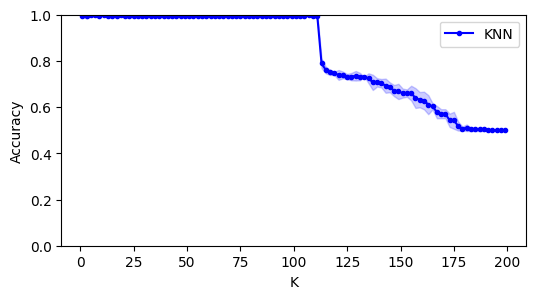

In [35]:
### TO RUN
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True)

Ks = np.arange(1, 200, 2)
accuracies_knn = np.zeros((len(Ks), n_splits))
for i, K in enumerate(Ks):
    model_knn = KNeighborsClassifier(n_neighbors=K)
    for k, idx in enumerate(kf.split(X_train, y_train)):
        (idx_learn, idx_val) = idx
        model_knn.fit(X_train[idx_learn], y_train[idx_learn])
        prediction_knn = model_knn.predict(X_train[idx_val])
        accuracies_knn[i, k] = accuracy(prediction_knn, y_train[idx_val])
means_knn = accuracies_knn.mean(axis=1)
stds_knn = accuracies_knn.std(axis=1)

"Plot"
plt.figure(figsize=(6, 3))

plt.plot(Ks, means_knn, ".-b", label="KNN")
plt.fill_between(Ks, means_knn - stds_knn, means_knn + stds_knn, alpha=0.2, color="b")
plt.ylim(0, 1)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Question:

- What do you conclude regarding the dependency of the accuracy on K for the KNN in this case? Does it hold for other sets of parameters for the data generation?

Now that we analysed the performance dependence on the hyperparameters, we can compare the two selected models on the ``test`` set.

In [36]:
### TO RUN
best_K = Ks[np.argmax(means_knn)]

print(f"Best K for KNN: {best_K}")

model_best_knn = KNeighborsClassifier(n_neighbors=best_K)
model_best_knn.fit(X_train, y_train)
prediction_best_knn = model_best_knn.predict(X_test)
accuracy_best_knn = accuracy(prediction_best_knn, y_test)
print(f"Accuracy best KNN : {100 * accuracy_best_knn:.2f} %")

model_lda = LDA()
model_lda.fit(X_train, y_train)
prediction_lda = model_lda.predict(X_test)
accuracy_lda = accuracy(prediction_lda, y_test)
print(f"Accuracy LDA : {100 * accuracy_lda:.2f} %")

Best K for KNN: 5
Accuracy best KNN : 100.00 %
Accuracy LDA : 100.00 %


### Question:
- From the output here above, which model will you choose at the end?

<font size=5 color=#009999> 2.2. Dimensionality reduction </font> <br>

It is sometimes good practice to reduce the dimensionality of a signal in order to get the main components of their distribution. A motivation is that usual norms behave counter-inuitively in high dimension. To reduce the dimensionality, we will use the ``Principal compenent analysis (PCA)`` proposed by sklearn. See the [associated Wikipedia page](https://en.wikipedia.org/wiki/Principal_component_analysis). We start by illustrating the interest of PCA with a toy example.

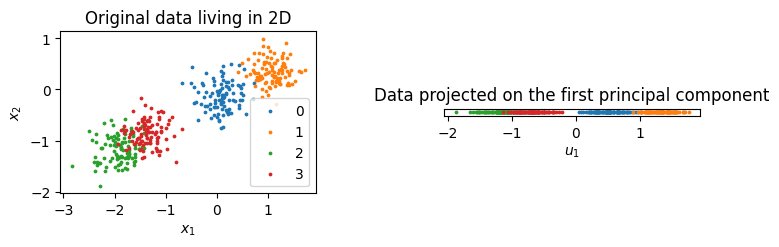

In [33]:
### TO RUN
N = 100  # Number of points per subcluster. (defaut: 100)
n_classes = 4  # Number of differents classes. (default: 4)
sig = 0.25  # Noise std. (default: 0.25)
np.random.seed(
    8
)  # For some reproducibility in the results, you can change the seed or remove this line if desired. (default: 1)

"Generate the data"
xc = np.random.randn(n_classes)
yc = 0.5 * xc - 0.2
cluster_centers = np.concatenate((xc[:, np.newaxis], yc[:, np.newaxis]), axis=1)
centers = np.repeat(cluster_centers, N, axis=0)
noise = sig * np.random.randn(n_classes * N, 2)
X = centers + noise

"Apply PCA on data to reduce dimensionality to 1D"
n = 1  # Number of principal components kept
pca = PCA(n_components=n, whiten=True)
X_reduced = pca.fit_transform(X)

"Plot"
s = 3.0
fig = plt.figure()
axs = [fig.add_axes([0.0, 0.0, 0.4, 1.0]), fig.add_axes([0.6, 0.0, 0.4, 1.0])]
axs[0].set_aspect("equal", adjustable="box")
axs[1].set_aspect("equal", adjustable="box")
for i in range(n_classes):
    axs[0].scatter(X[i * N : (i + 1) * N, 0], X[i * N : (i + 1) * N, 1], label=i, s=s)
    axs[1].scatter(X_reduced[i * N : (i + 1) * N], np.zeros(N), label=i, s=s)
axs[0].set_title("Original data living in 2D")
axs[1].set_title("Data projected on the first principal component")
axs[0].set_xlabel("$x_1$")
axs[0].set_ylabel("$x_2$")
axs[1].set_xlabel("$u_1$")
axs[1].set_yticks([])
axs[0].legend()
plt.show()

This hands-on session focuses on the simple KNN and LDA classifiers. However, there are many other that are worth giving a try using SKlearn. To give you motivation, run ``plot_classifier_comparison.py``